In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

In [2]:
# List of paths with .csv files
folder_names  = [
        "/mnt/c/users/helen/Desktop/WT_new",
        "/mnt/c/users/helen/Desktop/As_2h_new",
        "/mnt/c/users/helen/Desktop/As_4h_new",
]

folders = [Path(f) for f in folder_names]

In [3]:
# Data loading into single dataframe
dfs = []

for folder in folders:
    for file in folder.glob("*.csv"):

        df = pd.read_csv(file)

        # Add file name column
        df["file_name"] = file.stem

        dfs.append(df)

    # Combine all dataframes
    data = pd.concat(dfs, ignore_index=True)

    # Column ordering
    data = data[
        ["file_name", "ROI", "Area", "Mean"]
    ]

    # Rename ROI column to remove the suffix after the underscore
    data["ROI"] = data["ROI"].apply(lambda x: x.split("_")[0])
    
# Add new sample_name column
data['sample_name'] = data['file_name'].apply(lambda x: 'WT' if 'NO_AS' in x else ('Sodium_arsenite_2h' if '2h' in x else 'Sodium_arsenite_4h'))

In [6]:
# Optional: Save the combined dataframe to a new CSV file
data.to_csv("/mnt/c/users/helen/Desktop/combined_data.csv", index=False, sep=";", decimal=",")

In [9]:
data.tail()

,file_name,ROI,Area,Mean,sample_name
232,C2_2_MP_U2OS_fixed_WT_AS_100uM_4h.nd2_(series_...,Whole,980.333,2.321,Sodium_arsenite_4h
233,C2_2_MP_U2OS_fixed_WT_AS_100uM_4h.nd2_(series_...,Cytoplasm,766.998,1.765,Sodium_arsenite_4h
234,C2_3_MP_U2OS_fixed_WT_AS_100uM_4h.nd2_(series_...,Nucleus,276.757,10.781,Sodium_arsenite_4h
235,C2_3_MP_U2OS_fixed_WT_AS_100uM_4h.nd2_(series_...,Whole,511.563,6.324,Sodium_arsenite_4h
236,C2_3_MP_U2OS_fixed_WT_AS_100uM_4h.nd2_(series_...,Cytoplasm,234.786,1.071,Sodium_arsenite_4h


In [ ]:
# Filtration of outliters
#data = data[data['Mean'] < 20]

# Optional: Save the combined filtered dataframe to a new CSV file
#data.to_csv("/mnt/c/users/helen/Desktop/combined_data_filtered.csv", index=False, sep=";", decimal=",")

In [8]:
# Brief statistical summary of the data
data.groupby(['sample_name', 'ROI']).agg({'Area': ['mean', 'std', 'count'], 'Mean': ['mean', 'std']})

Area                        Mean  \
                                    mean         std count      mean   
sample_name        ROI                                                 
Sodium_arsenite_2h Cytoplasm  500.690346  290.196548    26  1.156500   
                   Nucleus    241.324885   67.842603    26  3.845577   
                   Whole      738.840615  324.058548    26  2.082346   
Sodium_arsenite_4h Cytoplasm  663.846567  278.762754    30  2.457233   
                   Nucleus    287.245300  108.339079    30  9.694500   
                   Whole      950.638900  349.867912    30  4.740233   
WT                 Cytoplasm  480.415609  329.606003    23  1.024174   
                   Nucleus    254.004000   70.747867    23  5.265130   
                   Whole      733.317174  355.925324    23  2.687739   

                                         
                                    std  
sample_name        ROI                   
Sodium_arsenite_2h Cytoplasm   0.861266  
                   Nucleus     2.268587  
                   Whole       1.089175  
Sodium_arsenite_4h Cytoplasm   3.708271  
                   Nucleus    10.130510  
                   Whole       5.572500  
WT                 Cytoplasm   0.659224  
                   Nucleus     3.429101  
                   Whole       1.920731

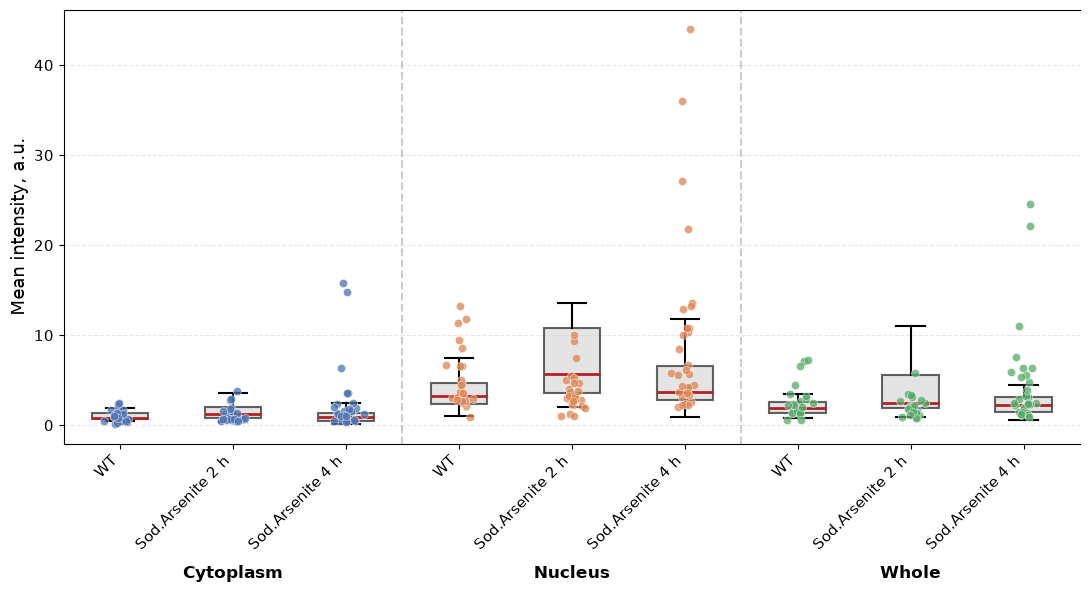

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

# Order of groups
roi_order = ["Cytoplasm", "Nucleus", "Whole"]
sample_order = ["WT", "Sodium_arsenite_2h", "Sodium_arsenite_4h"]

# Your custom sample names for x-axis
sample_labels = {
    "WT": "WT",
    "Sodium_arsenite_2h": "Sod.Arsenite 2 h",
    "Sodium_arsenite_4h": "Sod.Arsenite 4 h",
}

# -------------------------------------------------------
# Color boxes according to ROI
# -------------------------------------------------------
roi_colors = {
    "Cytoplasm": "#4C72B0",   # blue
    "Nucleus": "#DD8452",     # orange
    "Whole": "#55A868",       # green
}

# Prepare data in desired order
groups = []
labels = []
positions = []

pos = 1
for roi in roi_order:
    for sample in sample_order:
        values = data.loc[
            (data["ROI"] == roi) & (data["sample_name"] == sample),
            "Mean"
        ].dropna()

        groups.append(values)
        labels.append(sample_labels[sample])
        positions.append(pos)
        pos += 1


# -------------------------------------------------------
# Boxplots: all light gray
# -------------------------------------------------------
data.boxplot(
    column="Mean",
    by=["ROI", "sample_name"],
    ax=ax,
    grid=False,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray",
                  edgecolor="black",
                  linewidth=1.5,
                  alpha=0.6),
    medianprops=dict(color="firebrick", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)


# -------------------------------------------------------
# Overlay individual points
# -------------------------------------------------------
for i, (roi, sample) in enumerate(
    [(roi, sample) for roi in roi_order for sample in sample_order],
    start=1
):
    values = data.loc[
        (data["ROI"] == roi) & (data["sample_name"] == sample),
        "Mean"
    ].dropna()

    x = np.random.normal(i, 0.05, len(values))

    ax.scatter(
        x,
        values,
        color=roi_colors[roi],
        edgecolor="white",
        linewidth=0.4,
        s=35,
        alpha=0.75,
        zorder=3,
    )
    
# X-axis sample labels
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")

# ROI subgroup names below x-axis
roi_centers = {
    "Cytoplasm": 2,
    "Nucleus": 5,
    "Whole": 8,
}

for roi, center in roi_centers.items():
    ax.text(
        center,
        -0.28,
        roi,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontsize=12,
        fontweight="bold",
    )
    
# Optional vertical separators between ROIs
ax.axvline(3.5, color="gray", linestyle="--", alpha=0.4)
ax.axvline(6.5, color="gray", linestyle="--", alpha=0.4)
    
# Appearance
ax.set_ylabel("Mean intensity, a.u.", fontsize=13)
ax.set_xlabel("")


# Improve appearance
fig.suptitle("")
ax.set_title("")
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

# Optional: Save the figure to a file
plt.savefig("/mnt/c/users/helen/Desktop/boxplot.png", dpi=600, bbox_inches="tight")

# Show image
plt.show()

In [11]:
# Statistics - Mann-Whitney U test

roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", "Sodium_arsenite_2h"),
    ("WT", "Sodium_arsenite_4h"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        u, p = mannwhitneyu(x, y, alternative="two-sided")

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "U statistic": u,
            "p-value": p,
        })

stats_df = pd.DataFrame(results)

stats_df

,ROI,Group 1,Group 2,n1,n2,U statistic,p-value
0,Cytoplasm,WT,Sodium_arsenite_2h,23,26,283.0,0.756161
1,Cytoplasm,WT,Sodium_arsenite_4h,23,30,237.0,0.053706
2,Nucleus,WT,Sodium_arsenite_2h,23,26,358.0,0.241215
3,Nucleus,WT,Sodium_arsenite_4h,23,30,255.0,0.108236
4,Whole,WT,Sodium_arsenite_2h,23,26,344.0,0.372668
5,Whole,WT,Sodium_arsenite_4h,23,30,263.0,0.143576


In [13]:
# Optional: Save dataframe to a new CSV file
stats_df.to_csv("/mnt/c/users/helen/Desktop/u_test_results.csv", index=False, sep=";", decimal=",")

In [ ]:
# Statistics - T test
roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", "Sodium_arsenite_2h"),
    ("WT", "Sodium_arsenite_4h"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        t, p = ttest_ind(x, y, equal_var=False)

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "t statistic": t,
            "p-value": p,
        })

ttest_df = pd.DataFrame(results)

ttest_df

,ROI,Group 1,Group 2,n1,n2,t statistic,p-value
0,Cytoplasm,WT,Sodium_arsenite_2h,23,26,-0.597797,0.552845
1,Cytoplasm,WT,Sodium_arsenite_4h,23,30,-1.827346,0.073501
2,Nucleus,WT,Sodium_arsenite_2h,23,26,1.727424,0.090658
3,Nucleus,WT,Sodium_arsenite_4h,23,30,-2.006709,0.050096
4,Whole,WT,Sodium_arsenite_2h,23,26,1.377303,0.174943
5,Whole,WT,Sodium_arsenite_4h,23,30,-1.687975,0.097523


In [14]:
# Optional: Save dataframe to a new CSV file
ttest_df.to_csv("/mnt/c/users/helen/Desktop/t_test_results.csv", index=False, sep=";", decimal=",")